<a href="https://colab.research.google.com/github/Amikesh-CB/Emotion-Driven-Lip-Reading-System/blob/main/Emotion_Driven_Lip_Reading_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kaggle API setup in Colab

In [ ]:
!pip install kaggle

Upload Kaggle API key

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"himanshusaroj5","key":"c46340c6ea4874a1f928f8e2cc0182e7"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Lip reading dataset
!kaggle datasets download gpiosenka/lip-reading

# Facial emotion dataset
!kaggle datasets download msambare/fer2013

# GRID speech dataset
!kaggle datasets download stanfordu/gridcorpus

403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/gpiosenka/lip-reading
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
  0% 0.00/60.3M [00:00<?, ?B/s]
100% 60.3M/60.3M [00:00<00:00, 1.40GB/s]
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/stanfordu/gridcorpus


In [ ]:
!kaggle datasets download msambare/fer2013
!kaggle datasets download omkargurav/lipreading-dataset
!kaggle datasets download ejlok1/cremad

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
fer2013.zip: Skipping, found more recently modified local copy (use --force to force download)
403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/datasets/metadata/omkargurav/lipreading-dataset
Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
 85% 383M/451M [00:06<00:01, 66.8MB/s]
100% 451M/451M [00:06<00:00, 71.3MB/s]


In [ ]:
!ls

cremad.zip  fer2013.zip  kaggle.json  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/datasets

lip-reading-dataset.zip


In [2]:
#LIP READING EXPRESSION
!unzip /content/drive/MyDrive/datasets/lip-reading-dataset.zip -d /content/lipreading

unzip:  cannot find or open /content/drive/MyDrive/datasets/lip-reading-dataset.zip, /content/drive/MyDrive/datasets/lip-reading-dataset.zip.zip or /content/drive/MyDrive/datasets/lip-reading-dataset.zip.ZIP.


In [ ]:
!unzip fer2013.zip #FACIAL EMOTION RECOGNITION

In [ ]:
!unzip cremad.zip #VOICE EMOTION RECOGNITION

unzip:  cannot find or open cremad.zip, cremad.zip.zip or cremad.zip.ZIP.


In [ ]:
!ls

AudioWAV    drive	 kaggle.json  sample_data  train
cremad.zip  fer2013.zip  lipreading   test


In [ ]:
!ls train


angry  disgust	fear  happy  neutral  sad  surprise


In [ ]:
import tensorflow as tf

IMG_SIZE = 48
BATCH = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "train",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    color_mode="grayscale"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "test",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    color_mode="grayscale"
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(7,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48,48,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(7,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 123s 134ms/step - accuracy: 0.3650 - loss: 1.6068 - val_accuracy: 0.4540 - val_loss: 1.4316
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 136s 128ms/step - accuracy: 0.4870 - loss: 1.3433 - val_accuracy: 0.4968 - val_loss: 1.2932
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 149s 136ms/step - accuracy: 0.5341 - loss: 1.2282 - val_accuracy: 0.5224 - val_loss: 1.2500
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 118s 131ms/step - accuracy: 0.5661 - loss: 1.1483 - val_accuracy: 0.5277 - val_loss: 1.2320
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 116s 129ms/step - accuracy: 0.5927 - loss: 1.0747 - val_accuracy: 0.5443 - val_loss: 1.1994
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 114s 127ms/step - accuracy: 0.6248 - loss: 1.0022 - val_accuracy: 0.5372 - val_loss: 1.2249
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.6485 - loss: 0.9298 - val_accuracy: 0.5469 - val_loss: 1.2466
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 141s 127ms/step - accuracy: 0.6788 -

Confusion matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

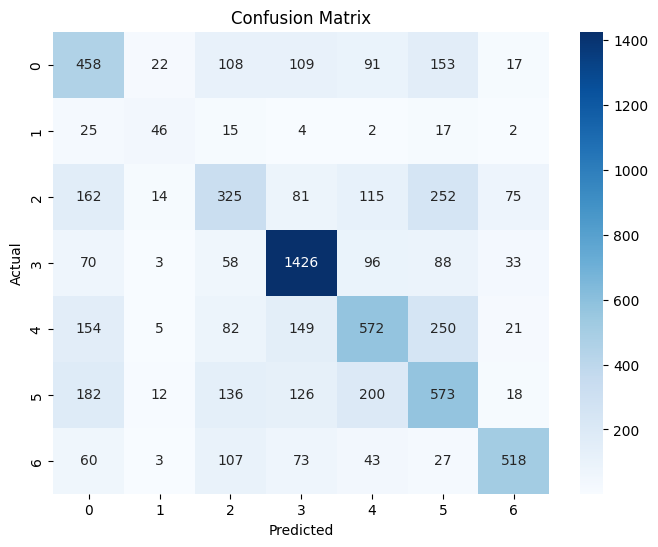

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!ls lipreading

outputs


In [ ]:
!ls -R lipreading | head -n 50

Lip Dataset Loader

In [ ]:
lip_ds = tf.keras.utils.image_dataset_from_directory(
    "lipreading/outputs",
    image_size=(64,64),
    batch_size=32
)

Found 14982 files belonging to 681 classes.


Lip reading CNN Model

In [ ]:
lip_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(50,activation='softmax')
])

In [ ]:
#compile
lip_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lip_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286,002 (4.91 MB)

 Trainable params: 1,286,002 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

Train lip-reading model

In [ ]:
!ls lipreading/outputs/a_1 | head

0.png
10.png
11.png
12.png
13.png
14.png
15.png
16.png
17.png
18.png


In [ ]:
import cv2
import numpy as np

X = []
y = []

img_size = 64

for label, cls in enumerate(classes):
    cls_path = os.path.join(base_path, cls)

    for root, dirs, files in os.walk(cls_path):
        for file in files:
            if file.endswith(".jpg") or file.endswith(".png"):
                img_path = os.path.join(root, file)

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, (img_size, img_size))

                X.append(img)
                y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(14982, 64, 64) (14982,)


In [ ]:
X = X.reshape(-1,64,64,1) / 255.0

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
import tensorflow as tf

lip_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(64,64,1)),

    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(len(classes),activation='softmax')
])

In [ ]:
#compile
lip_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lip_model.fit(
    X_train,
    y_train,
    validation_data=(X_test,y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 96s 243ms/step - accuracy: 7.5094e-04 - loss: 6.5264 - val_accuracy: 3.3367e-04 - val_loss: 6.5279
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 100s 268ms/step - accuracy: 8.3438e-04 - loss: 6.5245 - val_accuracy: 0.0000e+00 - val_loss: 6.5313
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 131s 239ms/step - accuracy: 7.5094e-04 - loss: 6.5238 - val_accuracy: 0.0000e+00 - val_loss: 6.5345
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 147s 253ms/step - accuracy: 0.0013 - loss: 6.5232 - val_accuracy: 0.0000e+00 - val_loss: 6.5373
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 241ms/step - accuracy: 0.0012 - loss: 6.5227 - val_accuracy: 0.0000e+00 - val_loss: 6.5401
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 88s 234ms/step - accuracy: 0.0012 - loss: 6.5223 - val_accuracy: 0.0000e+00 - val_loss: 6.5427
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 143s 236ms/step - accuracy: 0.0017 - loss: 6.5220 - val_accuracy: 0.0000e+00 - val_loss: 6.5451
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
print(X_train.shape)
print(y_train.shape)

(11985, 64, 64, 1)
(11985,)


Lip model evaluate

In [ ]:
loss, acc = lip_model.evaluate(X_test, y_test)
print("Lip model accuracy:", acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.0000e+00 - loss: 6.5514
Lip model accuracy: 0.0


Prediction Generate

In [ ]:
import numpy as np

y_pred = lip_model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step


Confusion Matrix Lip Model

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Heatmap Visualization

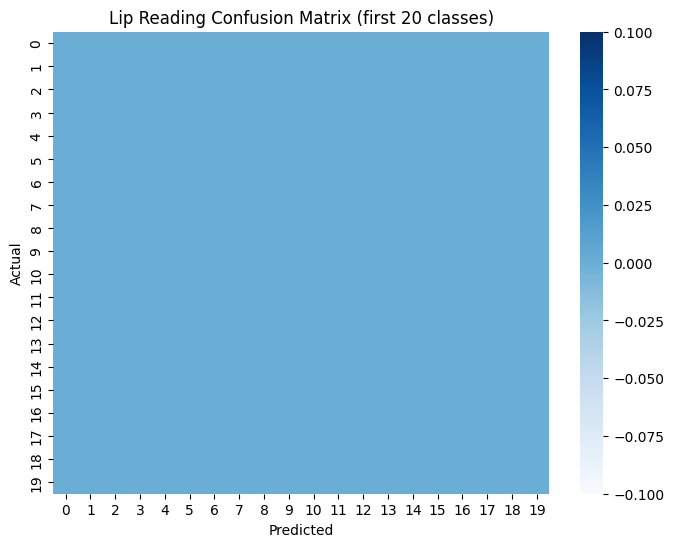

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm[:20,:20], cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Lip Reading Confusion Matrix (first 20 classes)")
plt.show()

In [ ]:
model.build((None,48,48,1))
lip_model.build((None,64,64,1))

Feature Extractor Model

In [ ]:
from tensorflow.keras.models import Model

emotion_feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

lip_feature_model = Model(
    inputs=lip_model.inputs,
    outputs=lip_model.layers[-2].output
)

In [ ]:
print(emotion_feature_model.summary())
print(lip_feature_model.summary())

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 354,944 (1.35 MB)

 Trainable params: 354,944 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     1,179,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,272,576 (4.85 MB)

 Trainable params: 1,272,576 (4.85 MB)

 Non-trainable params: 0 (0.00 B)

None


Extract Features

In [ ]:
#emotion Feature
emotion_features = emotion_feature_model.predict(test_ds)

225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step


In [ ]:
#Lip Feature
lip_features = lip_feature_model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step


In [ ]:
min_samples = min(len(emotion_features), len(lip_features))

emotion_features = emotion_features[:min_samples]
lip_features = lip_features[:min_samples]

print(emotion_features.shape)
print(lip_features.shape)

(2997, 128)
(2997, 256)


In [ ]:
#Feature fusion
import numpy as np

combined_features = np.concatenate(
    (emotion_features, lip_features),
    axis=1
)

print(combined_features.shape)

(2997, 384)


In [ ]:
#Final classifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

fusion_model = Sequential([
    Dense(128, activation='relu', input_shape=(384,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

fusion_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Graphs


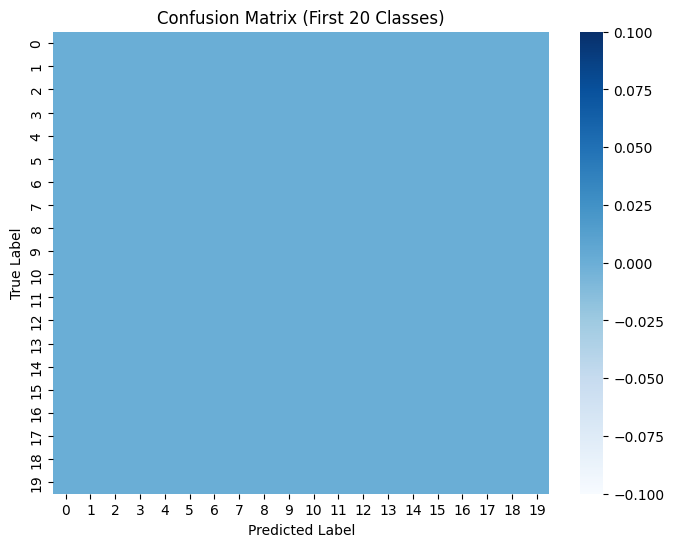

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(cm[:20,:20],
            cmap="Blues",
            annot=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (First 20 Classes)")

plt.show()

In [ ]:
history = model.fit(...)

ValueError: Unrecognized data type: x=Ellipsis (of type <class 'ellipsis'>)

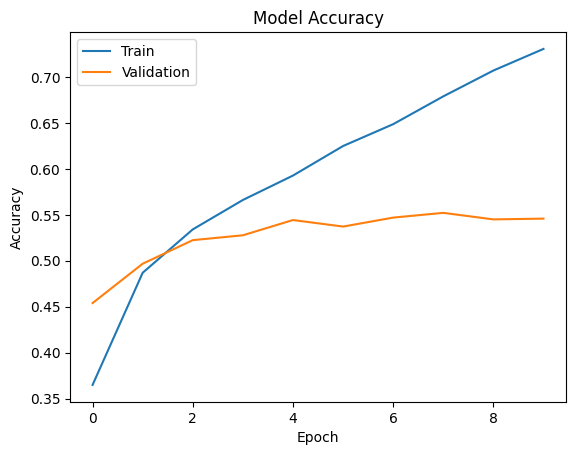

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

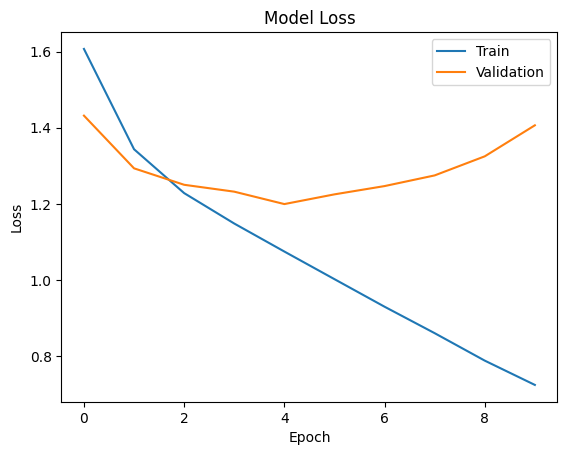

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train','Validation'])

plt.show()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving photo_2026-03-15_09-55-35.jpg to photo_2026-03-15_09-55-35.jpg


(np.float64(-0.5), np.float64(490.5), np.float64(507.5), np.float64(-0.5))

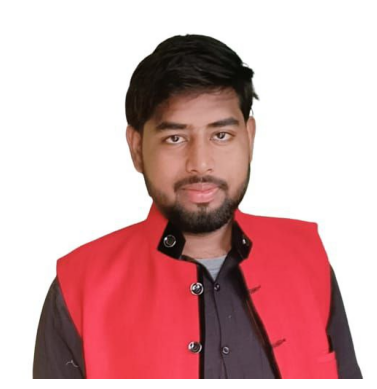

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(list(uploaded.keys())[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(img, 1.3, 5)

print("Faces detected:", len(faces))

Faces detected: 1


(np.float64(-0.5), np.float64(490.5), np.float64(507.5), np.float64(-0.5))

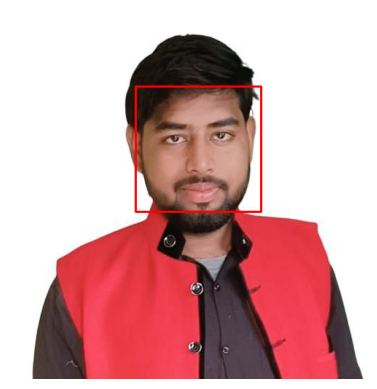

In [ ]:
for (x,y,w,h) in faces:
    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(255,0,0),2)

plt.imshow(img_rgb)
plt.axis("off")

In [ ]:
for (x,y,w,h) in faces:
    # Assuming mouth is in the lower half of the face
    mouth_y = y + int(h * 2/3)
    mouth_h = h - int(h * 2/3)
    mouth = img[mouth_y : mouth_y + mouth_h, x : x+w]

    mouth_gray = cv2.cvtColor(mouth, cv2.COLOR_BGR2GRAY)
    mouth_gray = cv2.resize(mouth_gray,(64,64))
    mouth_gray = mouth_gray.reshape(1,64,64,1)/255.0

    print(mouth_gray.shape)
    # For simplicity, we process only the first detected mouth.
    # If multiple faces are detected, this will only take the last one in the loop.
    break # Exit loop after processing the first face's mouth

(1, 64, 64, 1)


In [ ]:
pred = lip_model.predict(mouth_gray)

label = np.argmax(pred)

print("Predicted lip class:", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted lip class: 574


**Running Demo Model**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving photo_2026-03-15_09-45-52.jpg to photo_2026-03-15_09-45-52.jpg


(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

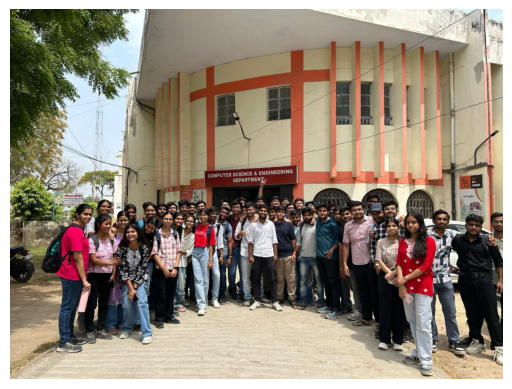

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(list(uploaded.keys())[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

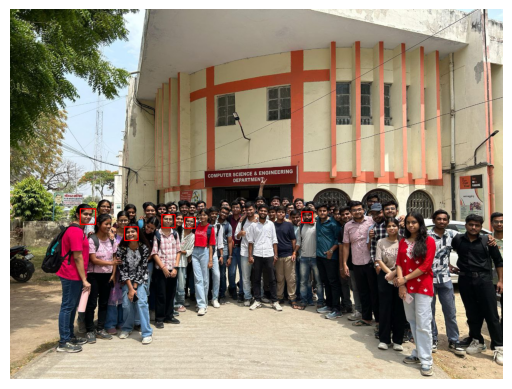

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(img,1.3,5)

for (x,y,w,h) in faces:
    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(255,0,0),2)

plt.imshow(img_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(1279.5), np.float64(959.5), np.float64(-0.5))

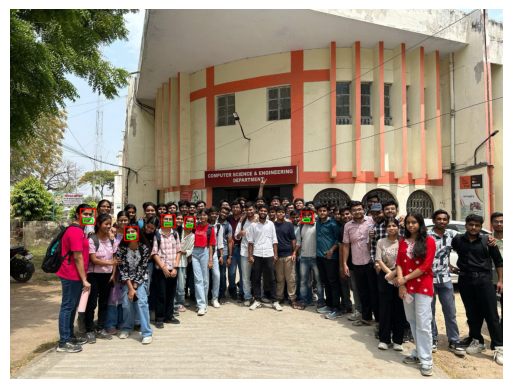

In [ ]:
for (x,y,w,h) in faces:

    # lips area calculation
    lip_x = x + int(w*0.2)
    lip_y = y + int(h*0.65)

    lip_w = int(w*0.6)
    lip_h = int(h*0.25)

    # draw GREEN rectangle
    cv2.rectangle(
        img_rgb,
        (lip_x,lip_y),
        (lip_x+lip_w,lip_y+lip_h),
        (0,255,0),   # green color
        2
    )

plt.imshow(img_rgb)
plt.axis("off")

In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(img,1.3,5)

print("Faces detected:",len(faces))

Faces detected: 5


(np.float64(-0.5), np.float64(33.5), np.float64(13.5), np.float64(-0.5))

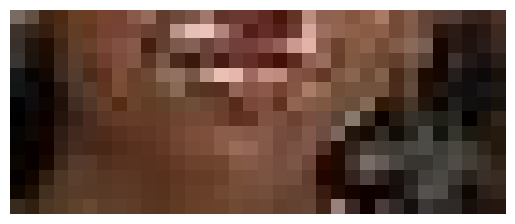

In [ ]:
for (x,y,w,h) in faces:

    face = img[y:y+h, x:x+w]

    mouth = face[int(h*0.6):h,:]

plt.imshow(cv2.cvtColor(mouth, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# Re-define the emotion detection model
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48,48,1)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(7,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

for (x,y,w,h) in faces:

    face = img[y:y+h, x:x+w]

    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face_gray = cv2.resize(face_gray,(48,48))
    face_gray = face_gray.reshape(1,48,48,1)/255.0

emotion_pred = model.predict(face_gray)

emotion_class = np.argmax(emotion_pred)

print("Detected Emotion:", emotion_labels[emotion_class])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
Detected Emotion: Angry


In [ ]:
import cv2
import numpy as np
import tensorflow as tf
import os

# Define base_path and classes if they are not already in scope
# This assumes 'lipreading/outputs' exists and contains class directories
base_path = "lipreading/outputs"
# Get class names from directory structure to correctly define the model's output layer
classes = sorted(os.listdir(base_path))

# Redefine and compile lip_model if it's not defined, to resolve NameError
# Note: This model will be untrained unless previous training cells are run.
if 'lip_model' not in locals() and 'lip_model' not in globals():
    lip_model = tf.keras.Sequential([
        tf.keras.layers.Rescaling(1./255, input_shape=(64,64,1)),

        tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256,activation='relu'),
        tf.keras.layers.Dense(len(classes),activation='softmax')
    ])

    lip_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print("lip_model was re-defined and compiled as it was not found in scope.")
    print("Warning: This re-defined model is untrained. Please run cells defining and training lip_model for accurate predictions.")

mouth_gray = cv2.cvtColor(mouth, cv2.COLOR_BGR2GRAY)
mouth_gray = cv2.resize(mouth_gray,(64,64))
mouth_gray = mouth_gray.reshape(1,64,64,1)/255.0

lip_pred = lip_model.predict(mouth_gray)

lip_class = np.argmax(lip_pred)

print("Lip class:", lip_class)

lip_model was re-defined and compiled as it was not found in scope.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
Lip class: 574


In [ ]:
from tensorflow.keras.models import Model

# Ensure base models are built
# model.build((None,48,48,1)) # Assuming 'model' is already built from previous executions
# lip_model.build((None,64,64,1)) # Assuming 'lip_model' is already built from previous executions

emotion_feature_model = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

lip_feature_model = Model(
    inputs=lip_model.inputs,
    outputs=lip_model.layers[-2].output
)

emotion_features = emotion_feature_model.predict(face_gray)
lip_features = lip_feature_model.predict(mouth_gray)

combined_features = np.concatenate(
    (emotion_features, lip_features),
    axis=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the fusion model (if not already defined)
fusion_model = Sequential([
    Dense(128, activation='relu', input_shape=(384,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

fusion_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fusion_pred = fusion_model.predict(combined_features)

final_class = np.argmax(fusion_pred)

print("Final multimodal prediction:", final_class)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Final multimodal prediction: 5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Detected Emotion: Neutral


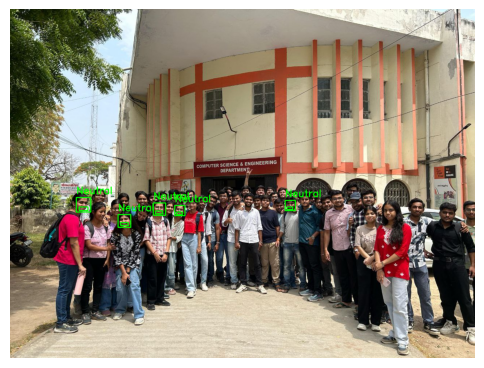

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

emotion_labels = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

# Redefine the emotion detection model within this cell to ensure it's available
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(48,48,1)),
    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(7,activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Note: This model has not been trained in this cell.
# For actual emotion prediction, ensure the model is loaded with trained weights
# or trained in a preceding cell.

img = cv2.imread(list(uploaded.keys())[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(img,1.3,5)

for (x,y,w,h) in faces:

    # face rectangle
    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,255,0),2)

    # lip area
    lip_x = x + int(w*0.2)
    lip_y = y + int(h*0.65)

    lip_w = int(w*0.6)
    lip_h = int(h*0.25)

    # lip rectangle
    cv2.rectangle(
        img_rgb,
        (lip_x,lip_y),
        (lip_x+lip_w,lip_y+lip_h),
        (0,255,0),
        2
    )

    # emotion detection
    face = img[y:y+h, x:x+w]

    face_gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
    face_gray = cv2.resize(face_gray,(48,48))
    face_gray = face_gray.reshape(1,48,48,1)/255

    emotion_pred = model.predict(face_gray)
    emotion_class = np.argmax(emotion_pred)

    emotion_text = emotion_labels[emotion_class]

    # text on image
    cv2.putText(
        img_rgb,
        emotion_text,
        (x,y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.9,
        (0,255,0),
        2
    )

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.axis("off")

print("Detected Emotion:", emotion_text)

speech Recognition

In [ ]:
!pip install -U transformers librosa
!pip install librosa joblib

In [ ]:
import librosa
import numpy as np

audio, sr = librosa.load(audio_file, sr=22050)

mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
mfcc = np.mean(mfcc.T, axis=0)
mfcc = mfcc.reshape(1, -1)

In [ ]:
import librosa
audio_path = "/content/drive/MyDrive/audio_2026-03-15_10-18-15.wav"
audio, sr = librosa.load(audio_path, sr=16000)


In [ ]:
import librosa

audio_path = "/content/drive/MyDrive/audio_2026-03-15_10-18-15.wav"

audio, sr = librosa.load(audio_path, sr=16000)

In [ ]:
text = result["text"].lower()

if "happy" in text:
    voice_emotion = "Happy"
elif "sad" in text:
    voice_emotion = "Sad"
elif "angry" in text:
    voice_emotion = "Angry"
elif "fear" in text:
    voice_emotion = "Fear"
elif "surprise" in text:
    voice_emotion = "Surprise"
else:
    voice_emotion = "Neutral"

print("Voice Emotion:", voice_emotion)

Voice Emotion: Neutral


In [ ]:
from transformers import pipeline

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base"
)

result = asr({"array": audio, "sampling_rate": sr})

print("Text:", result["text"])

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Text:  Hello my name is Shivanshu, 1-3-4. This is speech recognition.


**live** **record**


**MFCC** Fearure **extraction**

In [ ]:
import librosa
import numpy as np

audio, sr = librosa.load(audio_file, sr=22050)

mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
mfcc = np.mean(mfcc.T, axis=0)
mfcc = mfcc.reshape(1, -1)

/tmp/ipykernel_110623/2855286234.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [ ]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode

def record(seconds=5, filename="speech.wav"):

    display(Javascript("""
    async function recordAudio(sec){
      const stream = await navigator.mediaDevices.getUserMedia({audio:true});
      const recorder = new MediaRecorder(stream);
      const chunks = [];

      recorder.ondataavailable = e => chunks.push(e.data);

      recorder.start();
      await new Promise(resolve => setTimeout(resolve, sec*1000));
      recorder.stop();

      await new Promise(resolve => recorder.onstop = resolve);

      const blob = new Blob(chunks);
      const reader = new FileReader();
      reader.readAsDataURL(blob);

      return new Promise(resolve=>{
        reader.onloadend = ()=>resolve(reader.result);
      });
    }
    """))

    audio = eval_js(f"recordAudio({seconds})")
    audio_bytes = b64decode(audio.split(',')[1])

    with open(filename, "wb") as f:
        f.write(audio_bytes)

    return filename

In [ ]:
audio_file = record(5)

print("Audio saved:", audio_file)

<IPython.core.display.Javascript object>

Audio saved: speech.wav


In [ ]:
import librosa
from transformers import pipeline

audio, sr = librosa.load(audio_file, sr=16000)

asr = pipeline(
    "automatic-speech-recognition",
    model="openai/whisper-base"
)

result = asr({"array": audio, "sampling_rate": sr})

print("Text:", result["text"])

/tmp/ipykernel_110623/1115540909.py:4: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(audio_file, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Text:  Hello, my name is Patrick and this is Test.
